## 序列模型
### 训练
在了解了上述统计工具后，让我们在实践中尝试一下！ 首先，我们生成一些数据：使用正弦函数和一些可加性噪声来生成序列数据， 时间步为1,2,...,1000

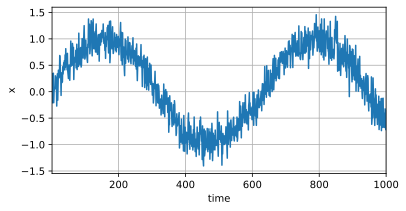

In [1]:
import torch
from torch import nn
from d2l import torch as d2l


T = 1000 # 产生1000个点
time = torch.arange(1,T+1,dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0,0.2,(T,))
d2l.plot(time, [x], 'time', 'x', xlim=[1,1000], figsize=(6, 3))

接下来，我们将这个序列转换为模型的特征－标签（feature-label）对。 基于嵌入维度$\tau $,我们将数据映射为数据对$y_{t}=x_{t}$和$\mathbf{x}_t=[x_{t-\tau},\ldots,x_{t-1}]$这比我们提供的数据样本少了$\tau $个， 因为我们没有足够的历史记录来描述前$\tau $个数据样本。 一个简单的解决办法是：如果拥有足够长的序列就丢弃这几项； 另一个方法是用零填充序列。 在这里，我们仅使用前600个“特征－标签”对进行训练。

In [2]:
tau = 4
# 据给定的时间序列 x 生成具有 tau 个滞后的特征序列和相应的标签序列。
features = torch.zeros((T-tau,tau))
for i in range(tau):
    features[:,i] = x[i:T-tau+i]
labels = x[tau:].reshape((-1,1))
batch_size,n_train=16,600
# 只有前n_train个样本用于训练
train_iter = d2l.load_array((features[:n_train], labels[:n_train]), batch_size, is_train=True)

在这里，我们使用一个相当简单的架构训练模型： 一个拥有两个全连接层的多层感知机，ReLU激活函数和平方损失。

In [3]:
# 初始化网络权重和的函数
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)
# 一个简单的多层感知机
def get_net():
    net = nn.Sequential(nn.Linear(4,10),nn.ReLU(),nn.Linear(10,1))
    net.apply(init_weights)
    return net
# 平方损失
loss = nn.MSELoss(reduction='none')

In [11]:
def train(net,train_iter,loss,epochs,lr):
    trainer = torch.optim.SGD(net.parameters(),lr=lr)
    for epoch in range(epochs):
        for X,y in train_iter:
            trainer.zero_grad()
            l = loss(net(X),y)
            l.sum().backward()
            trainer.step()
        print(f'epoch {epoch + 1}, '
              f'loss: {d2l.evaluate_loss(net, train_iter, loss):f}')

net = get_net()
train(net,train_iter,loss,5,0.01)


epoch 1, loss: 0.052932
epoch 2, loss: 0.052226
epoch 3, loss: 0.055270
epoch 4, loss: 0.049211
epoch 5, loss: 0.046424


### 预测
首先是检查模型预测下一个时间步的能力， 也就是单步预测（one-step-ahead prediction）。

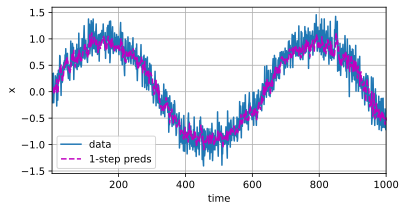

In [13]:
onestep_preds = net(features)
d2l.plot([time, time[tau:]],
         [x.detach().numpy(), onestep_preds.detach().numpy()], 'time',
         'x', legend=['data', '1-step preds'], xlim=[1, 1000],
         figsize=(6, 3))

正如我们所料，单步预测效果不错。 即使这些预测的时间步超过了600+4,其结果看起来仍然是可信的。 然而有一个小问题：如果数据观察序列的时间步只到604， 我们需要一步一步地向前迈进：我们必须使用我们自己的预测（而不是原始数据）来进行多步预测。 让我们看看效果如何。

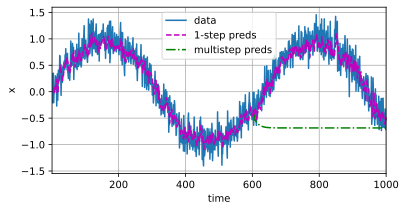

In [16]:
multistep_preds = torch.zeros(T)
multistep_preds[:n_train+tau] = x[:n_train+tau]
for i in range(n_train+tau,T):
    multistep_preds[i] = net(multistep_preds[i-tau:i].reshape((1,-1)))
d2l.plot([time, time[tau:], time[n_train + tau:]],
         [x.detach().numpy(), onestep_preds.detach().numpy(),
          multistep_preds[n_train + tau:].detach().numpy()], 'time',
         'x', legend=['data', '1-step preds', 'multistep preds'],
         xlim=[1, 1000], figsize=(6, 3))

如上面的例子所示，绿线的预测显然并不理想。 经过几个预测步骤之后，预测的结果很快就会衰减到一个常数。 为什么这个算法效果这么差呢？事实是由于错误的累积.基于k=1,4,16,64,通过对整个序列模型的计算，让我们更仔细地看一下k步预测的困难


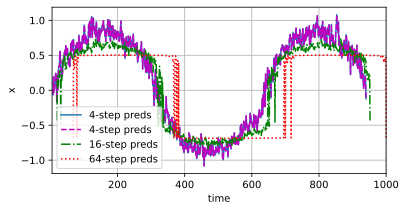

In [17]:
max_steps = 64
features = torch.zeros((T-tau-max_steps+1,tau+max_steps))
# 列i（i<tau）是来自x的观测，其时间步从（i）到（i+T-tau-max_steps+1）
for i in range(tau):
    features[:,i] = x[i:i+T-tau-max_steps+1]

# 列i（i>=tau）是来自（i-tau+1）步的预测，其时间步从（i）到（i+T-tau-max_steps+1）
for i in range(tau,tau+max_steps):
    features[:,i] = net(features[:,i-tau:i]).reshape(-1)

steps = (4,4,16,64)
d2l.plot([time[tau + i - 1: T - max_steps + i] for i in steps],
         [features[:, (tau + i - 1)].detach().numpy() for i in steps], 'time', 'x',
         legend=[f'{i}-step preds' for i in steps], xlim=[5, 1000],
         figsize=(6, 3))

### 小结
内插法（在现有观测值之间进行估计）和外推法（对超出已知观测范围进行预测）在实践的难度上差别很大。因此，对于所拥有的序列数据，在训练时始终要尊重其时间顺序，即最好不要基于未来的数据进行训练。

序列模型的估计需要专门的统计工具，两种较流行的选择是自回归模型和隐变量自回归模型。

对于时间是向前推进的因果模型，正向估计通常比反向估计更容易。

对于直到时间步t的观测序列，其在时间步t+k的预测输出是“k步预测”。随着我们对预测时间k值的增加，会造成误差的快速累积和预测质量的极速下降。